# KMeans Clustering
Importing the required libraries.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
%matplotlib inline

Creating the dataset using the `make_blobs`.

In [16]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)
X

array([[-5.21488849, -6.82734022],
       [-6.6344349 , -6.12605138],
       [-6.66871679, -4.46357107],
       ...,
       [ 3.28709102, -7.58831625],
       [ 4.56523563, -7.07737392],
       [ 2.20526099, -7.67875219]])

In [17]:
y

array([1, 1, 1, 1, 1, 2, 1, 0, 1, 0, 1, 0, 2, 0, 0, 1, 0, 1, 2, 1, 0, 0,
       0, 0, 2, 1, 0, 1, 2, 1, 0, 0, 0, 1, 0, 0, 0, 2, 2, 2, 0, 1, 1, 0,
       2, 1, 0, 2, 1, 1, 1, 1, 0, 2, 0, 0, 0, 0, 1, 1, 2, 0, 2, 1, 2, 1,
       1, 2, 1, 1, 2, 2, 0, 1, 0, 1, 1, 0, 2, 1, 1, 2, 0, 2, 1, 0, 2, 2,
       2, 2, 0, 1, 2, 1, 1, 1, 1, 0, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1,
       2, 1, 0, 2, 1, 1, 0, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 0, 0, 2, 1, 0,
       2, 2, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 1, 2, 0, 1, 2, 2, 1, 0,
       1, 2, 0, 1, 2, 1, 0, 1, 2, 2, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 2, 0, 1, 1, 1, 0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0,
       2, 0, 1, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 0, 2, 0, 1, 2, 0, 2, 2,
       2, 1, 2, 0, 0, 2, 2, 1, 2, 0, 2, 0, 2, 2, 0, 0, 0, 1, 1, 0, 2, 2,
       1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 1, 1,
       0, 1, 0, 1, 0, 2, 0, 1, 1, 0, 1, 2, 1, 1, 1,

Plotting the clusters in the graph for the visualization.

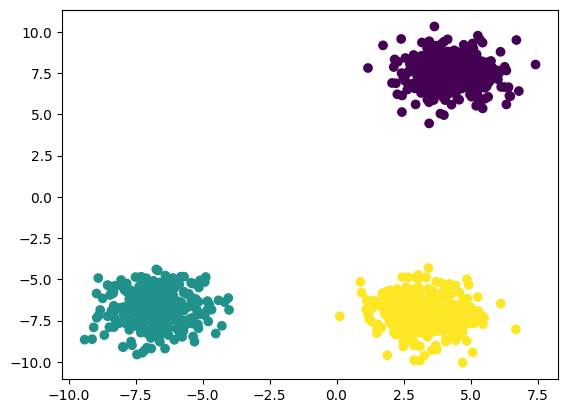

In [18]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

Standardization: Feature scaling technique

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [21]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.cluster import KMeans

Elbow method to select `K` value.

In [23]:
wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, init="k-means++")
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

Plotting the Elbow Curve.

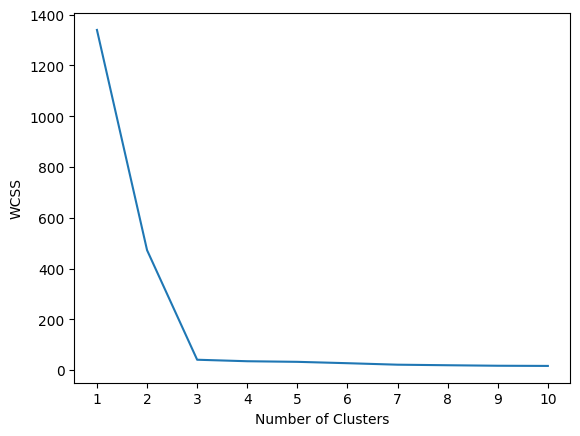

In [24]:
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In the above plotting, we can clearly see that the graphs becomes stable after the `K=3`. We will choose the value `3` as our number of clusters.

In [25]:
kmeans = KMeans(n_clusters=3, init="k-means++")
kmeans.fit_predict(X_train_scaled)

array([2, 1, 2, 0, 1, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 2, 0, 1, 2, 0, 0, 2, 1, 0, 2, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 2, 1, 1, 1, 2, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 2, 2, 2, 0,
       1, 0, 1, 2, 2, 2, 0, 0, 0, 2, 2, 0, 1, 1, 2, 2, 2, 1, 0, 2, 0, 2,
       0, 1, 2, 0, 2, 1, 0, 0, 2, 0, 2, 0, 1, 0, 1, 2, 2, 2, 1, 2, 2, 2,
       0, 2, 2, 0, 0, 1, 2, 0, 2, 2, 1, 1, 0, 2, 2, 2, 1, 1, 2, 0, 0, 2,
       0, 2, 2, 1, 1, 1, 2, 0, 2, 2, 0, 2, 2, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 2, 1, 0, 0, 1, 2, 1, 0, 0, 1, 2, 2, 1, 1, 1, 2, 1,
       2, 2, 2, 1, 0, 1, 2, 1, 1, 0, 1, 2, 0, 0, 1, 1, 1, 0, 0, 2, 2, 2,
       0, 1, 2, 1, 2, 1, 1, 1, 0, 1, 2, 0, 0, 2, 0, 0, 2, 1, 2, 1, 1, 2,
       0, 2, 1, 0, 2, 0, 2, 0, 0, 2, 1, 2, 2, 2, 2, 1, 0, 0, 2, 2, 1, 2,
       0, 1, 2, 0, 0, 1, 0, 1, 1, 1, 0, 2, 0, 2, 0, 0, 2, 0, 0, 2, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 1, 2, 2, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,

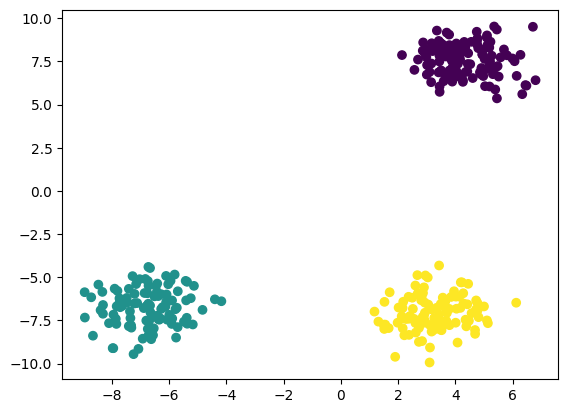

In [26]:
y_pred = kmeans.predict(X_test_scaled)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)
plt.show()

Validating the K value:
- KneeLocator
- Silhoutee Scoring

### KneeLocator
For this, we need to install one more library.

In [27]:
! pip install -q kneed

Using the WCSS Plotting, we need to decide the parameters like `curve` and `direction`.

In [29]:
from kneed import KneeLocator
kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
kl.elbow.item()

3

### Silhoutee Score
This one can be done using the `sklearn` library itself.

In [30]:
from sklearn.metrics import silhouette_score

silhoutte_coefficients = []
for k in range(2, 11):
  kmeans = KMeans(n_clusters=k, init="k-means++")
  kmeans.fit(X_train_scaled)
  score = silhouette_score(X_train_scaled, kmeans.labels_)
  silhoutte_coefficients.append(score)

In [33]:
silhoutte_coefficients

[np.float64(0.6563043165122541),
 np.float64(0.8460461569896721),
 np.float64(0.685669262572711),
 np.float64(0.5158810284629387),
 np.float64(0.3647769285083494),
 np.float64(0.35893257698916275),
 np.float64(0.34613489757468413),
 np.float64(0.3406432033592873),
 np.float64(0.33556745106145536)]

Plotting Silhouette Score.

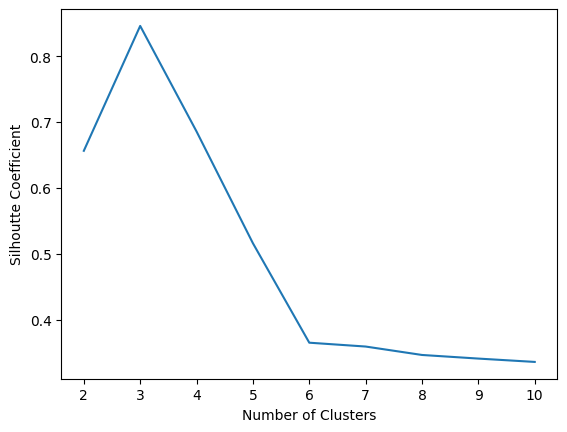

In [34]:
plt.plot(range(2, 11), silhoutte_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coefficient")
plt.show()

So, from the above plotted graph. Wherever the value is high, we choose that value of `K`.